# Target Revenue Analysis

Prepared by QuantFolio Solutions for Chapman Wealth Management. Data: Target Corp (TGT) quarterly revenue, qSales_2024.csv.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format

qSales = pd.read_csv('qSales_2024.csv')
target_sales = qSales.loc[qSales['tic'] == 'TGT'].copy()
target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])
target_sales['time'] = range(1, len(target_sales) + 1)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,"12,324.00",A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,"8,334.00",A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,"8,941.00",A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,"9,331.00",A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,"13,220.00",A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,"31,395.00",A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,"25,322.00",A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,"24,773.00",A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,"25,398.00",A,92


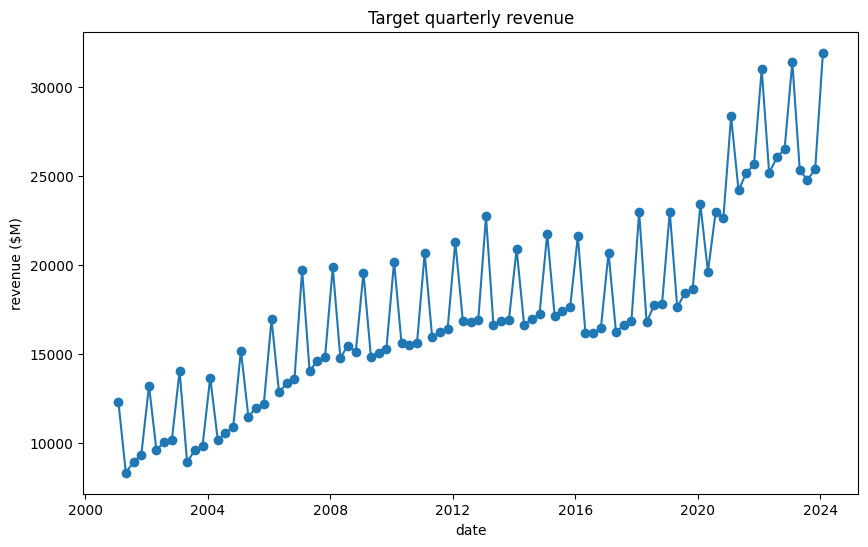

In [2]:
plt.figure(figsize=(10, 6))
plt.title('Target quarterly revenue')
plt.xlabel('date')
plt.ylabel('revenue ($M)')
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')
plt.show()

Two patterns stand out: a recurring spike every 4th quarter (fqtr = 4, Target's fiscal Q4, Nov-Jan holiday shopping), and a level shift starting around 2020, revenue steps up and stays up. Check both.

In [3]:
target_sales.groupby('fqtr')['saleq'].mean()

fqtr
1   15,868.43
2   16,407.65
3   16,608.22
4   21,099.46
Name: saleq, dtype: float64

In [4]:
target_sales.loc[(target_sales['datadate'] >= '2019-01-01') & (target_sales['datadate'] <= '2021-01-01'), ['datadate', 'saleq']]

,datadate,saleq
164,2019-01-31,"22,977.00"
165,2019-04-30,"17,627.00"
166,2019-07-31,"18,422.00"
167,2019-10-31,"18,664.00"
168,2020-01-31,"23,399.00"
169,2020-04-30,"19,615.00"
170,2020-07-31,"22,975.00"
171,2020-10-31,"22,632.00"


fqtr = 4 averages about \$21.1B vs \$15.9-16.6B for the other quarters, confirms the holiday spike. Revenue jumps from about \$18-19B per quarter in 2019 to \$22-23B from mid-2020 onward (COVID), and doesn't come back down. Two dummy variables:

holiday_dummy = 1 when fqtr == 4.

covid_dummy = 1 from time = 79 onward (2020-07-31, first quarter of the sustained jump).

In [5]:
target_sales['holiday_dummy'] = np.where(target_sales['fqtr'] == 4, 1, 0)
target_sales['covid_dummy'] = np.where(target_sales['time'] >= 79, 1, 0)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dummy,covid_dummy
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,"12,324.00",A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,"8,334.00",A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,"8,941.00",A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,"9,331.00",A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,"13,220.00",A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,"31,395.00",A,89,1,1
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,"25,322.00",A,90,0,1
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,"24,773.00",A,91,0,1
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,"25,398.00",A,92,0,1


## Train / test split

A strict 75/25 split would put the training cutoff at time = 69 (2018), before the covid_dummy ever turns on, so the model couldn't estimate a coefficient for it (it would be a column of zeros in training). Instead, the last 8 quarters (2 years) are held out as the test set, so training still includes 7 quarters of covid-era data.

In [6]:
dt4training = target_sales[:-8]
dt4testing = target_sales[-8:]

print(f"train = {len(dt4training)} quarters, {dt4training['datadate'].min().date()} to {dt4training['datadate'].max().date()}")
print(f"test  = {len(dt4testing)} quarters, {dt4testing['datadate'].min().date()} to {dt4testing['datadate'].max().date()}")

train = 85 quarters, 2001-01-31 to 2022-01-31
test  = 8 quarters, 2022-04-30 to 2024-01-31


## Build the model

revenue ~ time + holiday_dummy + covid_dummy

In [7]:
y = dt4training.loc[:, 'saleq']
x = dt4training.loc[:, ['time', 'holiday_dummy', 'covid_dummy']]
x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()
model1.params

const           9,535.06
time              128.85
holiday_dummy   4,675.76
covid_dummy     4,270.42
dtype: float64

In [8]:
model1.pvalues

const           0.00
time            0.00
holiday_dummy   0.00
covid_dummy     0.00
dtype: float64

revenue = 9,535.06 + 128.85 x time + 4,675.76 x holiday_dummy + 4,270.42 x covid_dummy

time, holiday_dummy and covid_dummy are all significant (p < 0.001). R2 = 0.93.

Regular quarter, pre-covid: revenue = 9,535.06 + 128.85 x time

Holiday quarter, pre-covid: revenue = 14,210.82 + 128.85 x time

Regular quarter, post-covid: revenue = 13,805.48 + 128.85 x time

Holiday quarter, post-covid: revenue = 18,481.24 + 128.85 x time

## Test the model

In [9]:
# covid_dummy is 1 for every row in the test set (all 8 quarters are post-2020),
# so it looks constant to add_constant, which then needs has_constant='add' to still add the real intercept.
x_test = dt4testing.loc[:, ['time', 'holiday_dummy', 'covid_dummy']]
x_test = sm.add_constant(x_test, has_constant='add')

model1_assessment = dt4testing.copy()
model1_assessment['predicted_saleq'] = model1.predict(x_test)
model1_assessment['abs_pct_error'] = abs(
    (model1_assessment['saleq'] - model1_assessment['predicted_saleq']) / model1_assessment['saleq']
)

mape = model1_assessment['abs_pct_error'].mean()
print(f'MAPE = {mape*100:.2f}%')

display(model1_assessment[['datadate', 'saleq', 'predicted_saleq', 'abs_pct_error']])

MAPE = 2.97%


,datadate,saleq,predicted_saleq,abs_pct_error
177,2022-04-30,"25,170.00","24,886.76",0.01
178,2022-07-31,"26,037.00","25,015.61",0.04
179,2022-10-31,"26,518.00","25,144.47",0.05
180,2023-01-31,"31,395.00","29,949.08",0.05
181,2023-04-30,"25,322.00","25,402.17",0.00
182,2023-07-31,"24,773.00","25,531.02",0.03
183,2023-10-31,"25,398.00","25,659.87",0.01
184,2024-01-31,"31,919.00","30,464.49",0.05


## Actual vs predicted

Predict across the full history (not just the test set) to see how well the model tracks Target's revenue overall.

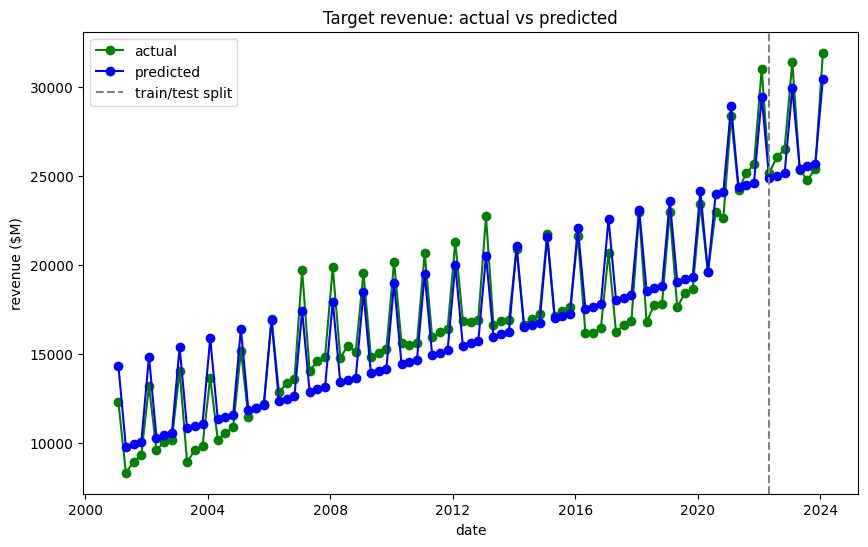

In [10]:
x_all = target_sales.loc[:, ['time', 'holiday_dummy', 'covid_dummy']]
x_all = sm.add_constant(x_all)
target_sales['predicted_saleq'] = model1.predict(x_all)

plt.figure(figsize=(10, 6))
plt.title('Target revenue: actual vs predicted')
plt.xlabel('date')
plt.ylabel('revenue ($M)')
plt.plot(target_sales['datadate'], target_sales['saleq'], color='green', marker='o', label='actual')
plt.plot(target_sales['datadate'], target_sales['predicted_saleq'], color='blue', marker='o', label='predicted')
plt.axvline(dt4testing['datadate'].iloc[0], color='gray', linestyle='--', label='train/test split')
plt.legend()
plt.show()

## Memo

To: Chapman Wealth Management
From: QuantFolio Solutions
Re: Target (TGT) revenue analysis

What the dummy variables capture: holiday_dummy flags Target's fiscal Q4 (Nov-Jan), the recurring holiday shopping quarter, worth about \$4.68B above trend every year. covid_dummy flags every quarter from mid-2020 onward and captures a separate, structural jump of about \$4.27B per quarter that has held steady for over 3 years, not a one-time spike.

How well the model explains revenue: R2 = 0.93 on the training data, and the held-out test MAPE is 2.97% (last 8 quarters). Time, the holiday dummy, and the covid dummy are all statistically significant (p < 0.001).

Key insights for the investment decision: Target has a steady underlying growth trend of about \$129M in revenue per quarter, independent of season or covid. The 2020 demand increase has not reverted after more than three years, so it looks like a durable shift in Target's revenue base rather than a temporary pandemic blip. Holiday-quarter seasonality is large and consistent, useful for setting quarter-by-quarter expectations. This model only explains revenue level, it says nothing about margins, competitive pressure, or costs, so it should support the revenue side of the investment thesis, not stand in for the full picture.